In [1]:
!pip install imbalanced-learn
!pip install shap


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset Shape: (284807, 31)

Class Distribution:
 Class
0    284315
1       492
Name: count, dtype: int64

Logistic Regression Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.11      0.89      0.20        98

    accuracy                           0.99     56962
   macro avg       0.56      0.94      0.60     56962
weighted avg       1.00      0.99      0.99     56962


XGBoost Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.39      0.85      0.54        98

    accuracy                           1.00     56962
   macro avg       0.70      0.92      0.77     56962
weighted avg       1.00      1.00      1.00     56962



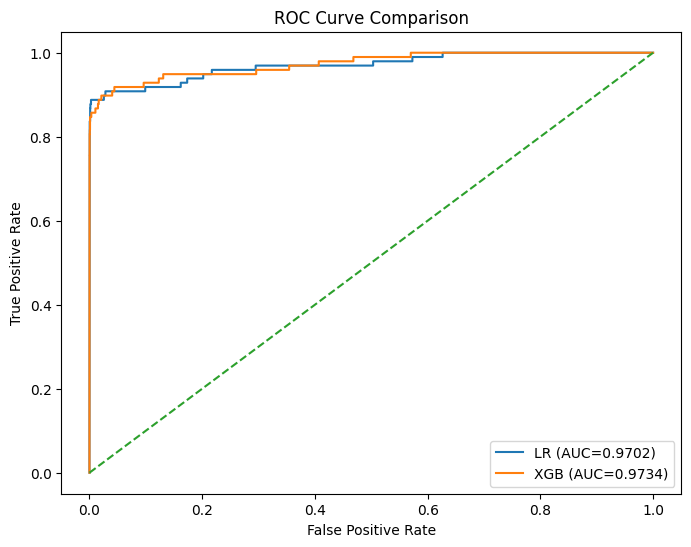

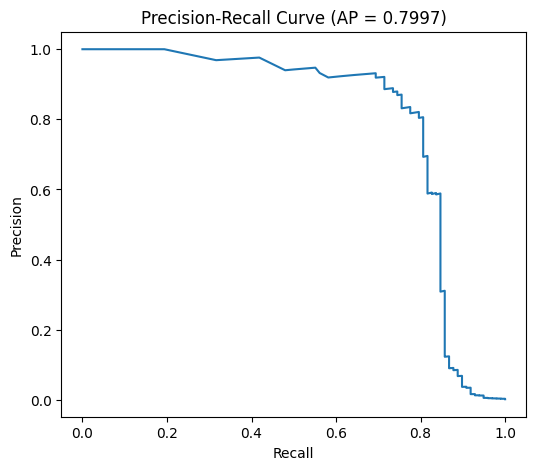


XGBoost ROC-AUC: 0.9734246874748773
XGBoost Average Precision: 0.799658895469689

Optimized Threshold: 0.8500000000000002

Optimized Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.58      0.85      0.69        98

    accuracy                           1.00     56962
   macro avg       0.79      0.92      0.84     56962
weighted avg       1.00      1.00      1.00     56962



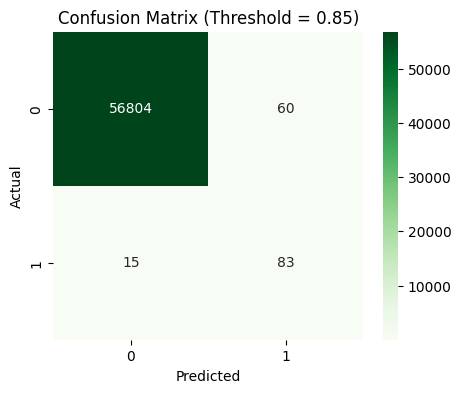

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE


df = pd.read_csv("creditcard.csv")

print("Dataset Shape:", df.shape)
print("\nClass Distribution:\n", df["Class"].value_counts())


X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


X_train_small = X_train.sample(100000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]


sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_small, y_train_small)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_scaled, y_train_res)

y_pred_lr = lr.predict(X_test_scaled)

print("\nLogistic Regression Report:\n")
print(classification_report(y_test, y_pred_lr))


scale_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    scale_pos_weight=scale_weight,
    eval_metric='logloss',
    random_state=42,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1
)

xgb.fit(X_train_res, y_train_res)

y_pred_xgb = xgb.predict(X_test)

print("\nXGBoost Report:\n")
print(classification_report(y_test, y_pred_xgb))


y_probs_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_probs_xgb = xgb.predict_proba(X_test)[:, 1]

auc_lr = roc_auc_score(y_test, y_probs_lr)
auc_xgb = roc_auc_score(y_test, y_probs_xgb)

plt.figure(figsize=(8,6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_probs_lr)
plt.plot(fpr_lr, tpr_lr, label=f"LR (AUC={auc_lr:.4f})")

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_probs_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f"XGB (AUC={auc_xgb:.4f})")

plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


precision, recall, _ = precision_recall_curve(y_test, y_probs_xgb)
ap_score = average_precision_score(y_test, y_probs_xgb)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {ap_score:.4f})")
plt.show()

print("\nXGBoost ROC-AUC:", auc_xgb)
print("XGBoost Average Precision:", ap_score)


thresholds = np.arange(0.1, 0.9, 0.05)

best_threshold = 0.5
best_f1 = 0

for thresh in thresholds:
    y_pred_thresh = (y_probs_xgb >= thresh).astype(int)
    report = classification_report(y_test, y_pred_thresh, output_dict=True)
    f1 = report['1']['f1-score']
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh


y_pred_optimized = (y_probs_xgb >= best_threshold).astype(int)

print("\nOptimized Threshold:", best_threshold)
print("\nOptimized Classification Report:\n")
print(classification_report(y_test, y_pred_optimized))


cm = confusion_matrix(y_test, y_pred_optimized)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix (Threshold = {best_threshold:.2f})")
plt.show()